Códigos sueltos para ejecución de tutoriales o  snippets de código relacionado con langchain, langraph y langsmith para interiorizar sus conceptos, diferencias y mecánicas de escritura así como su sintaxis

In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm) # Nodo del LLM
graph.add_edge(START, "mock_llm") # Borde del grafo que establece la conexión START y el nodo previamente definido
graph.add_edge("mock_llm", END) # Borde del grafo que establece la conexión entre el nodo LLM y el final del grafo
graph = graph.compile() # Compilador START -> mock_LLM -> END

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]}) # Invocar el grafo pasándole mensajes 
# muy al estilo de las APIs de OpenAI o Claude: Lista de diccionarios con claves role y mensaje: [{'role': '', 'content': ''}]

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='9e5835e0-157b-4e93-9bff-0548b69c7d4d'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='c307df22-252e-463c-b522-b3299c3098a4', tool_calls=[], invalid_tool_calls=[])]}

## API de grafos

In [ ]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model


model = init_chat_model(
    "claude-sonnet-4-6",
    temperature=0
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


def rest(a: int, b: int) -> float:
    """Rest `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a - b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools) #Vincula las tools al modelo

In [14]:
add.name

'add'

In [17]:
print(rest) # -> NO ES UNA TOOL, es una función. Si le coloco el 
#decorador de tool habilito métodos y propiedades de la tool
try:
    rest.name
except:
    print("No es tool")

<function rest at 0x7f0114974400>
No es tool


In [23]:
tools_by_name

{'add': StructuredTool(name='add', description='Adds `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x7f0114974180>),
 'multiply': StructuredTool(name='multiply', description='Multiply `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x7f0114974220>),
 'divide': StructuredTool(name='divide', description='Divide `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x7f0115625b20>)}

In [22]:
tools_by_name['add']

StructuredTool(name='add', description='Adds `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x7f0114974180>)

In [ ]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

# Definimos el estado del grafo para almacenar los mensaje y el número de llamadas a LLM
# es similar a como definimos modelos en la capa domain en los que usamos una clase y 
# declaramos que atributos y los tipos que deberían tener las implementaciones que
# usen ese modelo

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [19]:
# Aquí definimos un nodo modelo que se utiliza para llamar al LLM y decidir si llamar a una herramienta o no
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

In [21]:
from langchain.messages import ToolMessage
#El nodo herramienta se utiliza para llamar a las herramientas y devolver los resultados.


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

In [28]:
# 5. Definir la lógica final
# La función de arista condicional se utiliza para enrutar al nodo o extremo de la 
# herramienta según si el LLM realizó una llamada a la herramienta.

from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

In [29]:
if not None:
    print('hola')
else:
    print('está en None')

hola


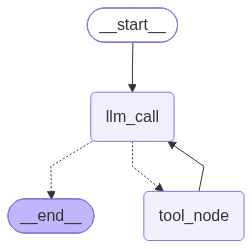

In [42]:
# 6. Compilar y construir el agente
# El agente se construye usando el StateGraph y compilado usando la compile método.

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [43]:
# Invoke
from langchain.messages import HumanMessage

messages = [HumanMessage(content="Deriva la expresión '3x**2 + 2' y luego dame la multiplicación de 4*3 y una vez que conozcas el resultado, tómalo y divídelo entre 2")]
messages = agent.invoke({"messages": messages})

count=0
for m in messages["messages"]:
    print(count)
    m.pretty_print()
    count += 1
    print("\n")

0
================================ Human Message =================================

Deriva la expresión '3x**2 + 2' y luego dame la multiplicación de 4*3 y una vez que conozcas el resultado, tómalo y divídelo entre 2


1
================================== Ai Message ==================================

[{'text': 'Voy a empezar con lo que puedo hacer en paralelo: calcular la derivada de forma analítica y la multiplicación de 4×3 al mismo tiempo.\n\n**Derivada de `3x² + 2`:**\nAplicando las reglas de derivación:\n- La derivada de `3x²` es `6x`\n- La derivada de `2` (constante) es `0`\n\n**∴ La derivada de `3x² + 2` es `6x`** ✅\n\nAhora, mientras tanto, calculo `4 × 3`:', 'type': 'text'}, {'id': 'toolu_01J2T5ZdM7b759aZE6BHxoni', 'caller': {'type': 'direct'}, 'input': {'a': 4, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01J2T5ZdM7b759aZE6BHxoni)
 Call ID: toolu_01J2T5ZdM7b759aZE6BHxoni
  Args:
    a: 4
    b: 3


2
================================= Tool M

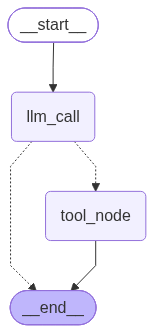

In [44]:
# Modifico el grafo para no tener el borde de tool hacia llm_call

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
# agent_builder.add_edge("tool_node", "llm_call") # -> COMENTADA PARA VER QUÉ PASA CON LA MISMA PREGUNTA

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [45]:
# Invoke
from langchain.messages import HumanMessage

messages = [HumanMessage(content="Deriva la expresión '3x**2 + 2' y luego dame la multiplicación de 4*3 y una vez que conozcas el resultado, tómalo y divídelo entre 2")]
messages = agent.invoke({"messages": messages})

count=0
for m in messages["messages"]:
    print(count)
    m.pretty_print()
    count += 1
    print("\n")

0
================================ Human Message =================================

Deriva la expresión '3x**2 + 2' y luego dame la multiplicación de 4*3 y una vez que conozcas el resultado, tómalo y divídelo entre 2


1
================================== Ai Message ==================================

[{'text': 'Voy a empezar con lo que puedo hacer en paralelo: calcular la derivada de forma analítica y la multiplicación de 4×3 al mismo tiempo.\n\n**Derivada de `3x² + 2`:**\nAplicando las reglas de derivación:\n- La derivada de `3x²` es `6x`\n- La derivada de `2` (constante) es `0`\n\n**∴ d/dx(3x² + 2) = 6x**\n\nAhora, simultáneamente calculo `4 × 3`:', 'type': 'text'}, {'id': 'toolu_01U7PCYuZFSdJbg3X3p2ngTw', 'caller': {'type': 'direct'}, 'input': {'a': 4, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01U7PCYuZFSdJbg3X3p2ngTw)
 Call ID: toolu_01U7PCYuZFSdJbg3X3p2ngTw
  Args:
    a: 4
    b: 3


2
================================= Tool Message =========

Conclusión: Al modificar el nodo doble vía entre el llm_call y el nodo tool no se pudo hacer la siguiente operación porque el agente solo tuvo acceso a la tool 1 vez y luego pasó al END


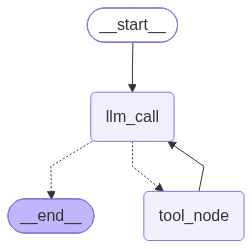

In [46]:
# Modifico el grafo para no tener el borde de tool hacia llm_call

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_edge("tool_node", "llm_call") # -> Modifico la definición, primero el borde y luego el borde condicional

agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [47]:
# Invoke
from langchain.messages import HumanMessage

messages = [HumanMessage(content="Deriva la expresión '3x**2 + 2' y luego dame la multiplicación de 4*3 y una vez que conozcas el resultado, tómalo y divídelo entre 2")]
messages = agent.invoke({"messages": messages})

count=0
for m in messages["messages"]:
    print(count)
    m.pretty_print()
    count += 1
    print("\n")

0
================================ Human Message =================================

Deriva la expresión '3x**2 + 2' y luego dame la multiplicación de 4*3 y una vez que conozcas el resultado, tómalo y divídelo entre 2


1
================================== Ai Message ==================================

[{'text': "Voy a empezar con lo que puedo hacer en paralelo: derivar la expresión y calcular la multiplicación de 4×3 al mismo tiempo.\n\n> 📐 **Derivada de `3x² + 2`:**\n> Aplicando las reglas de derivación:\n> - La derivada de `3x²` es `6x`\n> - La derivada de la constante `2` es `0`\n>\n> ∴ **f'(x) = 6x**\n\nAhora, simultáneamente calculo la multiplicación:", 'type': 'text'}, {'id': 'toolu_01D6uoGaHGqu6bz99GhRo5CN', 'caller': {'type': 'direct'}, 'input': {'a': 4, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01D6uoGaHGqu6bz99GhRo5CN)
 Call ID: toolu_01D6uoGaHGqu6bz99GhRo5CN
  Args:
    a: 4
    b: 3


2
================================= Tool Message ===

Conclusión: en la lógica definida no hubo cambio si definía primero el edge y luego el conditional_edge o visceversa

# Cómo de declara el estado 

funciones reducer: Especifican cómo aplicar actualizaciones al 

El estado puede ser un TypeDict o un modelo Pydantic

TODOS los nodos emitirán actualizaciones del estado

- TypeDict es la manera princiapl de definicir el estado. 
- Si se requieren valores por default entonces usar dataclass
- Pydantic solo si se requiere validación de datos recursiva (qué significa esto? tal vez que cada vez que el estado se actualiza entonces pydantic verifica los tipos de datos)

Se pueden agregar estados privados a nodos específicos y definir esquemas específicos para engrada y salidas del grafo e incluso un estado interno 

In [1]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph


class InputState(TypedDict):
    user_input: str


class OutputState(TypedDict):
    graph_output: str


class OverallState(TypedDict):
    foo: str
    user_input: str
    graph_output: str


class PrivateState(TypedDict):
    bar: str


def node_1(state: InputState) -> OverallState:
    # Write to OverallState
    return {"foo": state["user_input"] + " name"}


def node_2(state: OverallState) -> PrivateState:
    # Read from OverallState, write to PrivateState
    return {"bar": state["foo"] + " is"}


def node_3(state: PrivateState) -> OutputState:
    # Read from PrivateState, write to OutputState
    return {"graph_output": state["bar"] + " Lance"}


builder = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()
graph.invoke({"user_input": "My"})
# {'graph_output': 'My name is Lance'}

{'graph_output': 'My name is Lance'}

# Qué devuelve un nodo

 un nodo puede escribir en cualquier canal de estados en el estado del grafo. El estado del grafo es la unión de los canales de estados definidos en la inicialización, que incluye OverallState y los filtros InputState y OutputState.

 Un nodo devuelve un estado actualizado. Cualquier canal de estado en el grafo puede ser escrito desde un nodo

In [ ]:
StateGraph()

# Qué hace un reducer y cuándo se necesita

Una función reductora establece cómo se actualiza el estado en un nodo. Cada clave en el estado tiene su propia función reductora. Se necestia cuando quiero customizar el comportamiento de actualización del estado.

SI NO SE HACE ESPECÍFICA se asume que todas las actualizaciones de la clave deben sobreescribirla.

Los reductores ason funciones con 2 funciones posiciones left y right, siendo left el estado anterior y right el resultado de la modificación del nodo. Así pues, por default se reemplaza, o uno podría hacer reductores personalizados que modifiquen el estado en una manera particular, por ejemplo sumándolo: 

```python
from typing import Annotated

from typing_extensions import TypedDict


def append_strings(left: list[str], right: list[str]) -> list[str]:
    """Combine the existing state value (left) with a node update (right)."""
    return left + right


class State(TypedDict):
    tags: Annotated[list[str], append_strings]

```

Suppose the state is {"tags": ["draft"]} and a node returns {"tags": ["review"]}. LangGraph calls:


```python
append_strings(left=["draft"], right=["review"])  # returns ["draft", "review"]
```

Para espeficiar un reductor personalizado se debe declarar en el estado:

```python
from operator import add
from typing import Annotated

from typing_extensions import TypedDict


class State(TypedDict):
    foo: int
    bar: Annotated[list[str], add]
```

# Qué campos voy a declarar en mi estado

In [ ]:
from researchos.domain import Document
from dataclasses import dataclass, field
from langgraph.graph import add_messages

@dataclass
class State:
    query: str
    documents: list[Document] = field(default_factory=list)
    answer: str = ""
    messages: Annotated[list, add_messages] = field(default_factory=list)
    rewritten_query: str = ""